## Setup for EDA and time series 

In [152]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name

from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing

#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100



In [ ]:
from statsmodels.tsa.stattools import adfuller
!pip install pmdarima --quiet
import pmdarima as pm
require(forecast)

### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [153]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [154]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [155]:
#res_df.dtypes

In [156]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [157]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [158]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [159]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [160]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [161]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [162]:
data_df_gwh = data_df_mwh.copy()

In [163]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [164]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [165]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [166]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [167]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [168]:

data_df= data_df_gwh.copy()

In [169]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [170]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [171]:
##data_df.columns

In [172]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [173]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
#main_0  = 'Total_energy_generation_gwh' # This is only for energy
main_0  = 'Solar_gwh' # for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
#target = 'Total_energy_generation_gwh'
target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Solar energy in GWh
Solar(GWh)


### Here we set the function for line plot  

In [174]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



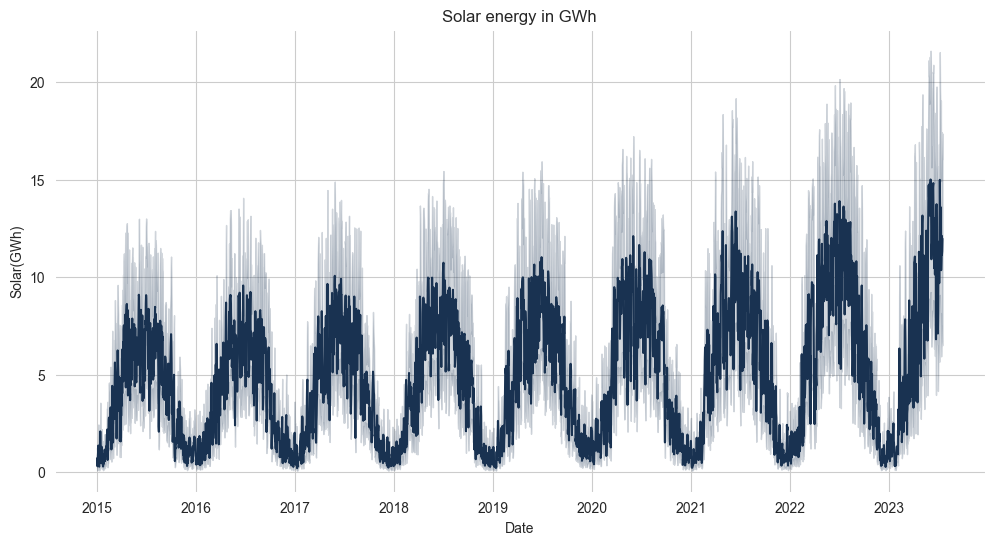

In [175]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [176]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [177]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [178]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

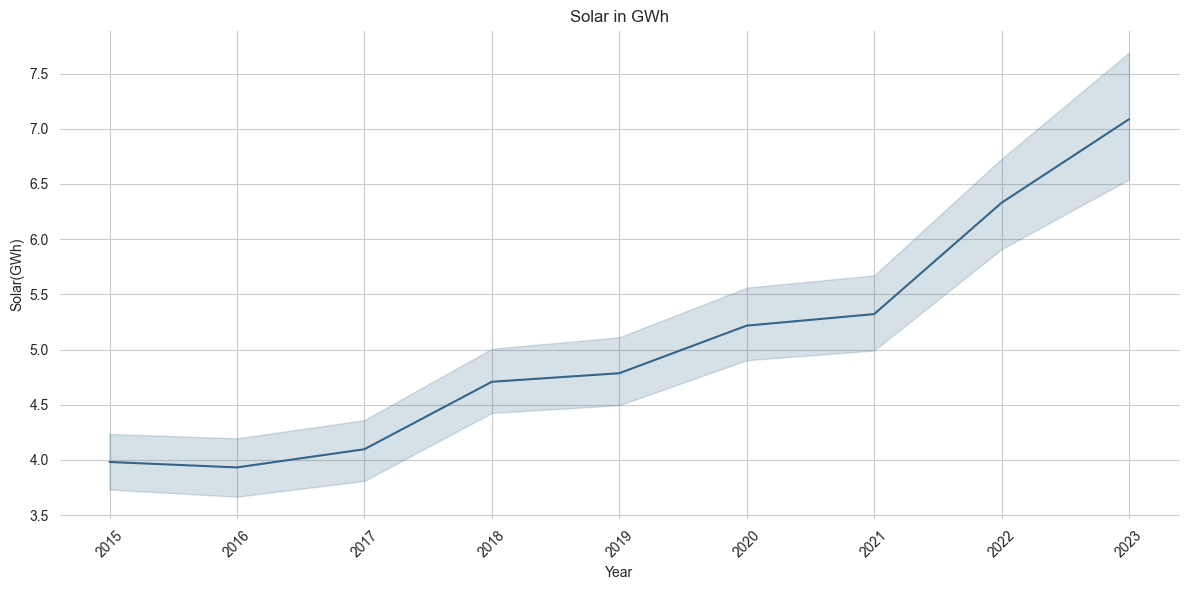

In [179]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [180]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [181]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Solar_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,0.00000
2015-01-01,2015,1,1,1,1,0.00000
2015-01-01,2015,1,1,1,2,0.00000
2015-01-01,2015,1,1,1,3,0.00000
2015-01-01,2015,1,1,1,4,0.00000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,10.08425
2023-07-17,2023,7,17,198,19,4.72400
2023-07-17,2023,7,17,198,20,1.51125


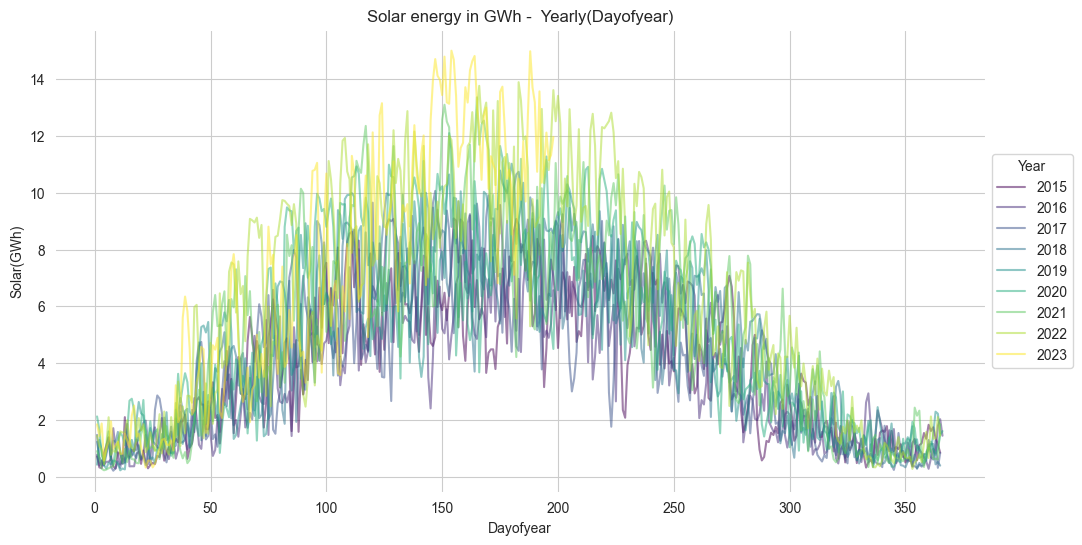

In [182]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [183]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [184]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')



#### Input parameters for auto_arima    
-   'seasonal',    boolean (True or False) to indicate the presence of seasonality
-   'm',           integer, the number of periods in a season
-   'start_p',     integer, the starting range for the order of the autoregressive component (p)
-   'd',           integer, the degree of differencing
-   'start_q',     integer, the starting range for the order of the moving average component (q)
-    'max_p',      integer, the upper bound for the order of the autoregressive component (p)
-    'max_d',      integer, the upper bound for the degree of differencing
-    'max_q',      integer, the upper bound for the order of the moving average component (q)
-    'start_P',    integer, the starting range for the seasonal autoregressive component (P)
-    'D',          integer, the degree of seasonal differencing
-    'start_Q',    integer, the starting range for the seasonal moving average component (Q)
-    'max_P',      integer, the upper bound for the seasonal autoregressive component (P)
-    'max_D',      integer, the upper bound for the degree of seasonal differencing
-    'max_Q',      integer, the upper bound for the seasonal moving average component (Q)
-    'stepwise'    boolean, True to enable the stepwise search for the best model



### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [185]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

#df_arima = data_df[target]
#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

In [186]:
data_df['SE_Detrend'] = (data_df[target] - data_df[target].shift(30))

ADF Test:
Null Hypothesis: Not Stationary
ADF Statistic: -49.641772
p-value: 0.000000
----------------------------------------
KPSS Test:
Null Hypothesis: Stationary
KPSS Statistic: 0.001847
p-value: 0.100000
----------------------------------------


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_18223/3170577137.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test = kpss(Solar_Energy_target_, regression='c', nlags='legacy', store=False)


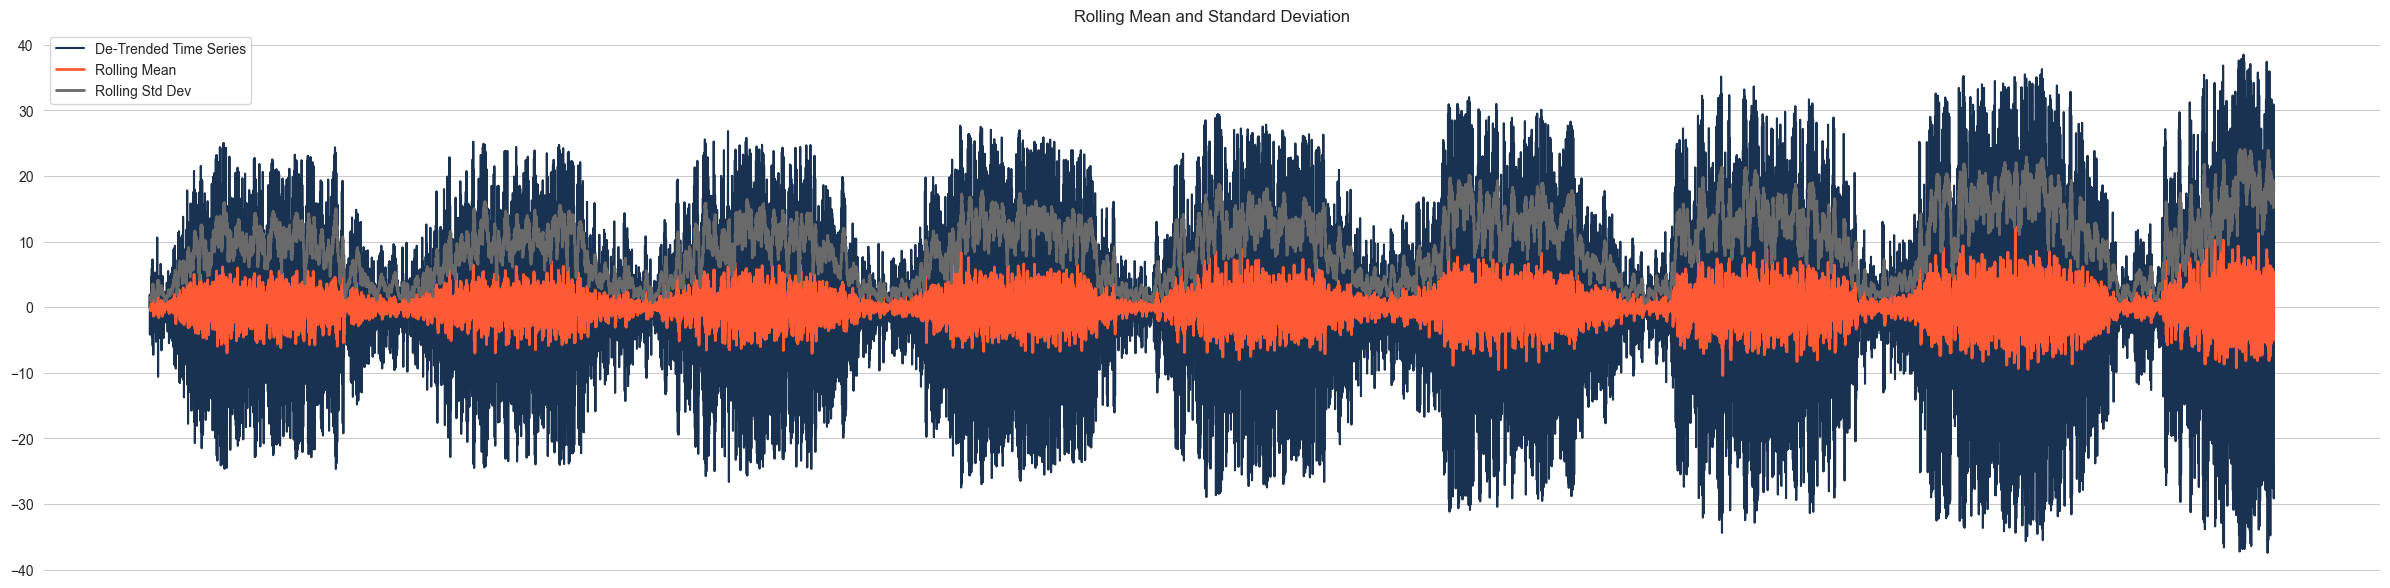

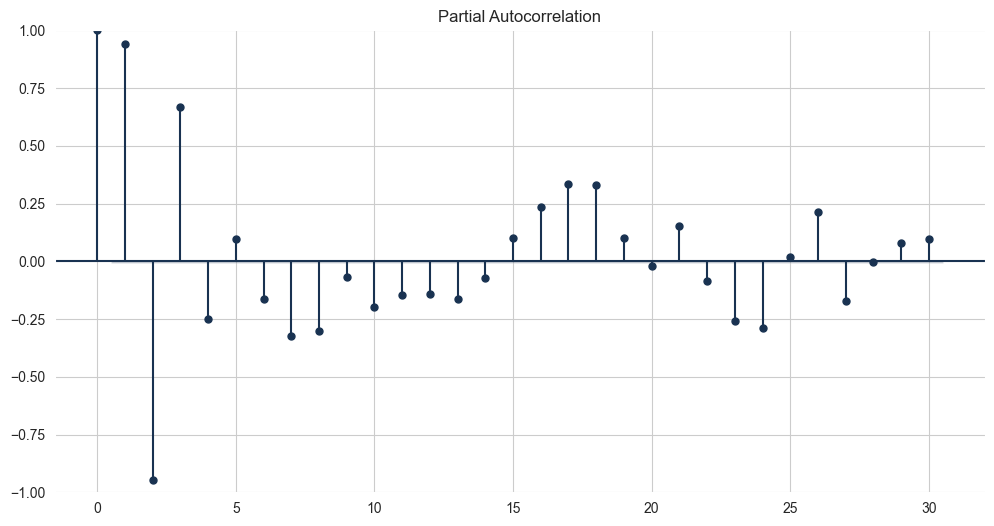

In [187]:
# Test for stationarity after de-trending 
def stationarity_test(Solar_Energy_target_):
    
    # Calculate rolling mean and rolling standard deviation
    rolling_mean = Solar_Energy_target_.rolling(30).mean()
    rolling_std_dev = Solar_Energy_target_.rolling(30).std()
  
    # Plot the statistics
    plt.figure(figsize=(24,6))
    plt.plot(Solar_Energy_target_,label='De-Trended Time Series')
    plt.plot(rolling_mean, label='Rolling Mean',linewidth=2.0)
    plt.plot(rolling_std_dev, label = 'Rolling Std Dev',linewidth=2.0)
    plt.xticks([])
    plt.legend(loc='best')
    plt.title('Rolling Mean and Standard Deviation')
    plt.tight_layout()
    
    # ADF test
    print("ADF Test:")
    adf_test = adfuller(Solar_Energy_target_,autolag='AIC')
    print('Null Hypothesis: Not Stationary')
    print('ADF Statistic: %f' % adf_test[0])
    print('p-value: %f' % adf_test[1])
    print('----'*10)
    
    # KPSS test
    print("KPSS Test:")
    kpss_test = kpss(Solar_Energy_target_, regression='c', nlags='legacy', store=False)
    print('Null Hypothesis: Stationary')
    print('KPSS Statistic: %f' % kpss_test[0])
    print('p-value: %f' % kpss_test[1])
    print('----'*10)
    
stationarity_test(data_df['SE_Detrend'].dropna())
#stationarity_test(data_df[target].dropna())

# Partial Autocorrelation Plot
pacf = plot_pacf(data_df['SE_Detrend'].dropna(), lags=30)
#pacf = plot_pacf(data_df[target].dropna(), lags=30)

#df.dropna()

In [188]:
data_df = data_df.dropna(subset=['SE_Detrend'])
# Resetting the indices using df.reset_index()
data_df = data_df.reset_index(drop=True)
data_df.isnull().sum()

Area                                    0
Mtu                                     0
Biomass_gwh                             0
Fossil_brown_coal_gwh                   0
Fossil_coal_derived_gas_gwh             0
Fossil_gas_gwh                          0
Fossil_hard_coal_gwh                    0
Fossil_oil_gwh                          0
Fossil_oil_shale_gwh                    0
Fossil_peat_gwh                         0
Geothermal_gwh                          0
Hydro_pumped_storage_aggregated_gwh     0
Hydro_pumped_storage_consumption_gwh    0
Hydro_run_of_river_and_poundage_gwh     0
Hydro_water_reservoir_gwh               0
Marine_gwh                              0
Nuclear_gwh                             0
Other_gwh                               0
Other_renewable_gwh                     0
Solar_gwh                               0
Waste_gwh                               0
Wind_offshore_gwh                       0
Wind_onshore_gwh                        0
Date                              

In [189]:
data_df.shape

(74849, 34)

In [190]:
#stationarity_test(data_df['SE_Detrend'].dropna())
#data_df['SE_Detrend']
#data_df['SE_Detrend'].isnull().sum()
#stationarity_test(data_df['SE_Detrend'].dropna())
#data_df.dropna(axis=1, inplace=True)
#data_df.isnull().sum()

In [191]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear', 'SE_Detrend'],
      dtype='object')

In [192]:
target= 'SE_Detrend'
dfs = data_df[['Date',  target]]
dfs_d = data_df[target]
x = 'Date'
y = target
dfs

,Date,SE_Detrend
0,2015-01-02,0.00000
1,2015-01-02,0.00000
2,2015-01-02,0.03800
3,2015-01-02,0.25250
4,2015-01-02,0.66675
...,...,...
74844,2023-07-17,-21.16275
74845,2023-07-17,-26.93425
74846,2023-07-17,-29.15275
74847,2023-07-17,-27.87850


In [193]:
#data_df['SE_Detrend'] = (data_df[target] - data_df[target].shift(30))

In [194]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear,SE_Detrend
0,Germany (DE),20150102 06:00-07:00,3.92200,8.76825,0.0,1.18825,2.74950,0.18375,0.0,0.0,...,6,57.59075,0.000000,57.59075,26.51075,2015,1,2,2,0.00000
1,Germany (DE),20150102 07:00-08:00,3.93825,8.92025,0.0,1.25350,3.26200,0.18400,0.0,0.0,...,7,59.78575,0.000000,59.78575,26.34500,2015,1,2,2,0.00000
2,Germany (DE),20150102 08:00-09:00,3.94475,9.98825,0.0,1.27675,3.92675,0.18375,0.0,0.0,...,8,63.14350,0.060180,63.10550,26.49325,2015,1,2,2,0.03800
3,Germany (DE),20150102 09:00-10:00,3.92300,10.96975,0.0,1.28400,4.14350,0.18375,0.0,0.0,...,9,65.32075,0.386554,65.06825,25.98625,2015,1,2,2,0.25250
4,Germany (DE),20150102 10:00-11:00,3.91875,11.87925,0.0,1.29625,4.22575,0.18325,0.0,0.0,...,10,67.27850,0.991030,66.61175,25.79775,2015,1,2,2,0.66675


In [195]:
##print(dfs.shape)
##plt.figure()
##plt.plot(dfs['Date'], dfs[target])
##plt.autoscale(enable=True, axis='x', tight=True)
##plt.show();


##Split data into train and test set
##window=365*24
##df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
##df_arima = df_arima.dropna()

([], [])

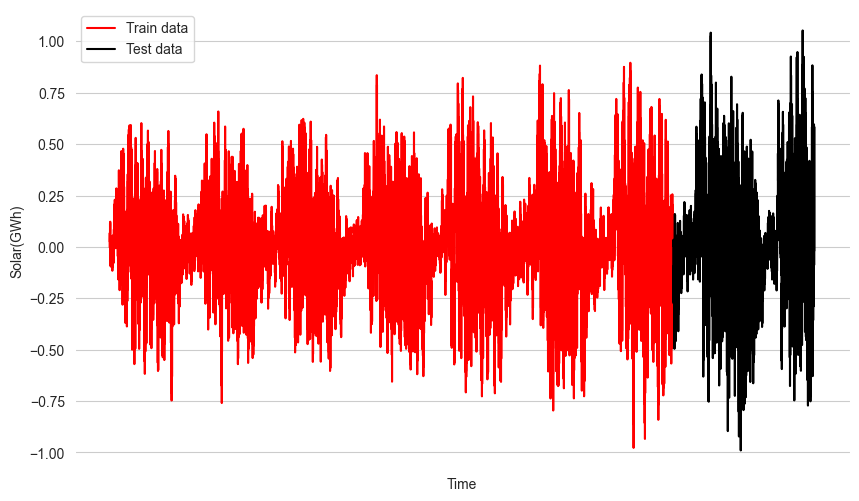

In [197]:
window=365#*24
df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
df_arima = df_arima.dropna()

#df_arima = dfs[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]
##
##
# Plotting the train and test set
plt.figure(figsize=(10,6))
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.plot(train_data, 'red', label='Train data')
plt.plot(test_data, 'black', label='Test data')
plt.legend()
plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[4] intercept   : AIC=-465712.206, Time=127.58 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=-19432.593, Time=3.87 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=-220325.940, Time=36.32 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=inf, Time=57.50 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=-19431.738, Time=0.90 sec
 ARIMA(2,0,2)(0,0,1)[4] intercept   : AIC=-475057.026, Time=146.54 sec
 ARIMA(2,0,2)(0,0,0)[4] intercept   : AIC=-465815.690, Time=54.16 sec
 ARIMA(2,0,2)(0,0,2)[4] intercept   : AIC=-469828.845, Time=204.18 sec
 ARIMA(2,0,2)(1,0,0)[4] intercept   : AIC=-466638.700, Time=122.57 sec
 ARIMA(2,0,2)(1,0,2)[4] intercept   : AIC=-463449.796, Time=232.52 sec
 ARIMA(1,0,2)(0,0,1)[4] intercept   : AIC=-375240.259, Time=109.77 sec
 ARIMA(2,0,1)(0,0,1)[4] intercept   : AIC=inf, Time=84.04 sec
 ARIMA(3,0,2)(0,0,1)[4] intercept   : AIC=-523011.387, Time=184.48 sec
 ARIMA(3,0,2)(0,0,0)[4] intercept   : AIC=-522999.439, Time=

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Auto-Arima RMSE :- 0.257


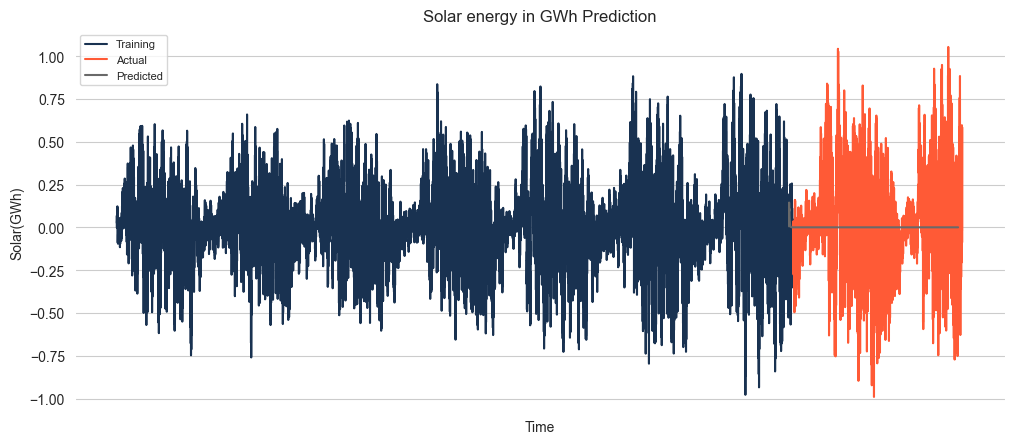

In [198]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=4, seasonal= True, test='adf',error_action='ignore',  
                      suppress_warnings=True,scoring='mse', alpha=0.1,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

In [40]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=6, seasonal= True,scoring='mse', alpha=0.1,stepwise=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(1,0,1)[2] intercept   : AIC=-396370.196, Time=114.37 sec
 ARIMA(0,0,0)(0,0,0)[2] intercept   : AIC=375799.927, Time=0.63 sec
 ARIMA(1,0,0)(1,0,0)[2] intercept   : AIC=inf, Time=44.15 sec
 ARIMA(0,0,1)(0,0,1)[2] intercept   : AIC=inf, Time=24.06 sec
 ARIMA(0,0,0)(0,0,0)[2]             : AIC=658683.165, Time=0.29 sec
 ARIMA(1,0,1)(0,0,1)[2] intercept   : AIC=-347692.946, Time=63.76 sec
 ARIMA(1,0,1)(1,0,0)[2] intercept   : AIC=-386161.095, Time=84.77 sec
 ARIMA(1,0,1)(2,0,1)[2] intercept   : AIC=-331489.119, Time=86.11 sec
 ARIMA(1,0,1)(1,0,2)[2] intercept   : AIC=-396036.192, Time=157.94 sec
 ARIMA(1,0,1)(0,0,0)[2] intercept   : AIC=-288886.459, Time=49.23 sec
 ARIMA(1,0,1)(0,0,2)[2] intercept   : AIC=-366882.338, Time=168.61 sec
 ARIMA(1,0,1)(2,0,0)[2] intercept   : AIC=-345304.490, Time=96.65 sec
 ARIMA(1,0,1)(2,0,2)[2] intercept   : AIC=-387926.234, Time=214.91 sec
 ARIMA(0,0,1)(1,0,1)[2] intercept   : AIC=67789477.704, Time=38

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Auto-Arima RMSE :- 12.612


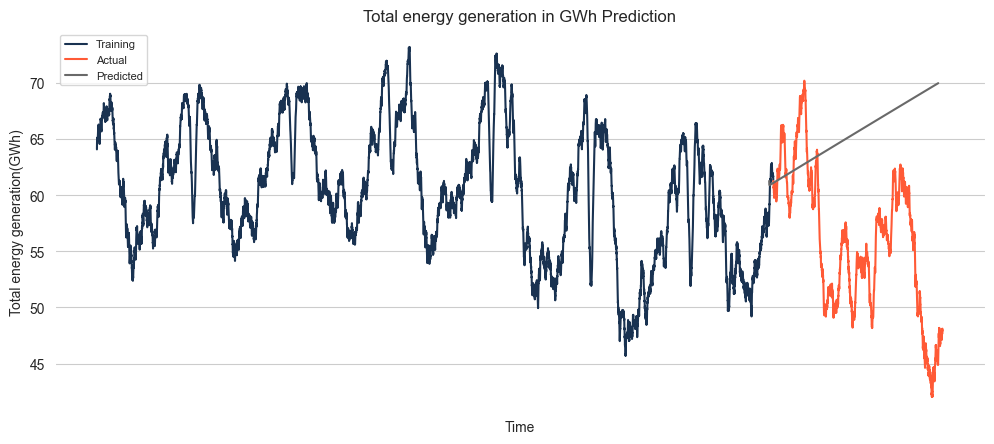

In [39]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=2, seasonal=True,
                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
                      suppress_warnings=True,scoring='mse', alpha=0.1,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pmdarima/arima/_validation.py:62: UserWarning: m (6) set for non-seasonal fit. Setting to 0
  warnings.warn("m (%i) set for non-seasonal fit. Setting to 0" % m)


Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-307990.803, Time=3.56 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=658683.165, Time=0.30 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=1.83 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=3.52 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-424417.666, Time=5.48 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=3.37 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=inf, Time=27.69 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-437437.655, Time=8.10 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-361362.495, Time=7.31 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=-449299.756, Time=4.22 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=nan sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=-449819.846, Time=6.48 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-443285.254, Time=18.17 sec
 ARIMA(4,0,3)(0,0,0)[0]             : AIC=-449863.741, Time=11.44 sec
 ARIMA(5,0,3)(0,0,0)[0]       

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Auto-Arima RMSE :- 7.941


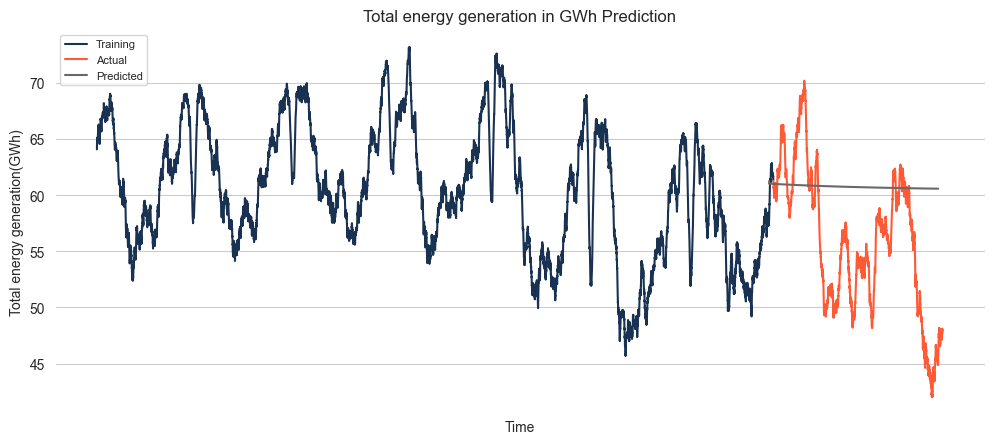

In [40]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=6, seasonal=False,
                      start_p=1, start_q=1, max_order=4, test='adf',error_action='ignore',  
                      suppress_warnings=True,scoring='mse', alpha=0.1,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))
#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

In [ ]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=6, seasonal=True,
                      start_p=0, start_q=0, max_order=4, test='adf',error_action='ignore',  
                           suppress_warnings=True,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

Performing stepwise search to minimize aic


In [2]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data,seasonal=True, m=4, scoring='mse', start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1,D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
#arima_model = auto_arima(train_data,start_p=1,start_q=1,test='adf',max_p=3,max_q=3,m=4,start_P=0,seasonal=True,d=None, D=1,trace=False
#                         ,error_action='ignore',suppress_warnings=True, stepwise=True)
#
arima_model = auto_arima(train_data,m=1, seasonal=True,
                      start_p=0, start_q=0, max_order=4, test='adf',error_action='ignore',  
                      suppress_warnings=True,scoring='mse', alpha=0.1,
                      stepwise=True, trace=True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.1) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

NameError: name 'train_data' is not defined

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Fri, 28 Jul 2023   AIC                         212691.140
Time:                        17:03:18   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

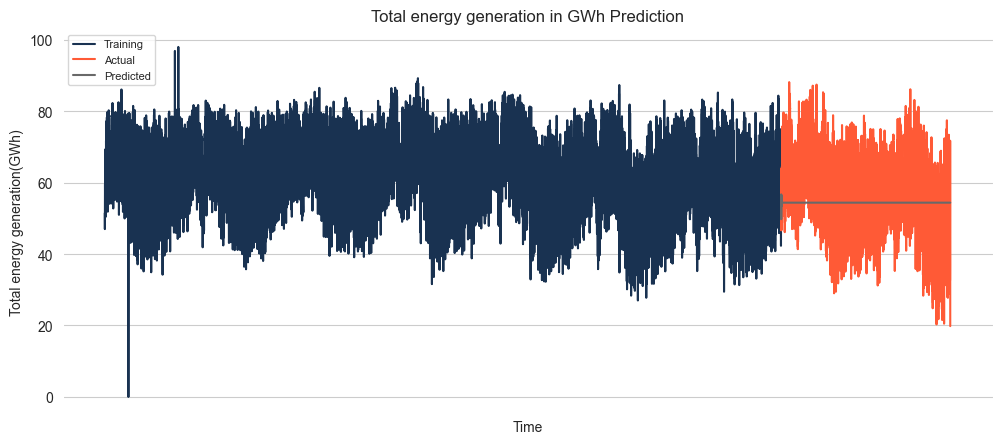

In [ ]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
#arima_model = auto_arima(train_data, scoring='mse', seasonal = Ture, m=7)
#from pmdarima.arima import auto_arima

# Specify the parameter settings
stepwise = True
seasonal = False#
p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]
P_values = [0, 1]
D_values = [0, 1]
max_order = None  # Set a specific value if you want to limit the maximum order

# Use the modified parameter settings
#auto_arima(train_data, start_p=0, start_q=0, test='adf', max_p=None, max_q=None, m=2, start_P=0, seasonal=seasonal, d=None, D=None, trace=False, error_action='ignore', suppress_warnings=True, stepwise=stepwise, random=True, random_state=42, n_fits=10, max_order=max_order, p_values=p_values, d_values=d_values, q_values=q_values, P_values=P_values, D_values=D_values)
arima_model =auto_arima(train_data, start_p=0, start_q=0, test='adf', max_p=None, max_q=None, m=2, start_P=0, seasonal=seasonal, d=None, D=None, trace=False, error_action='ignore', suppress_warnings=True, stepwise=stepwise, random=True, random_state=42, n_fits=10, max_order=max_order, p_values=p_values, d_values=d_values, q_values=q_values, P_values=P_values, D_values=D_values)

# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                52896
Model:             SARIMAX(3, 2, 2)x(1, 0, [1], 4)   Log Likelihood              384481.659
Date:                             Fri, 28 Jul 2023   AIC                        -768945.318
Time:                                     17:56:33   BIC                        -768865.434
Sample:                                          0   HQIC                       -768920.360
                                           - 52896                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -1.127e-08   5.77e-08     -0.195      0.845   -1.24e-07    1.02e-07
ar.L1          1.2428      

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Auto-Arima RMSE :- 11.558


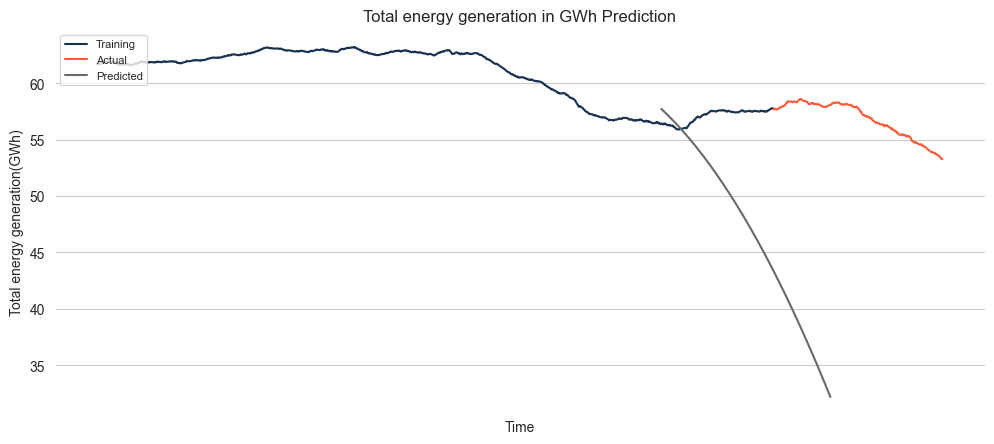

In [ ]:
# Auto ARIMA Method
#arima_model = auto_arima(train_data,
#                      start_p=1, start_q=1,
#                      max_p=5, max_q=5,
#                      test='adf',        
#                      trace=True,
#                      alpha=0.05,
#                      scoring='mse',
#                      suppress_warnings=True,
#                      seasonal = False
#                      )
arima_model = auto_arima(train_data, seasonal = True, m=4, scoring='mse', stepwise= True)


# Fit the final model with the order
fitted_model = arima_model.fit(train_data) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.05) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Auto-Arima RMSE :- " + str(round(rms_auto_arima,3)))

#plt.savefig("visualisations/Stock_ARIMA.png",dpi=300)

In [ ]:
# Perform time series decomposition
#result = seasonal_decompose(dfs[target], model='additive', period=365)

# Split the data into train and test sets
dfarima = dfs[target]
train_test_split_ratio = int(len(dfarima)*0.8)
train, test = dfarima[:train_test_split_ratio], dfarima[train_test_split_ratio:]

# Fit an auto_arima model to the training set
#model = auto_arima(train, start_p=1, start_q=1, max_p=3, max_q=3, m=12, start_P=0, seasonal=True, d=1, D=1, trace=True, error_action='ignore', suppress_warnings=True)
#model = auto_arima(train, start_p=1, start_q=1, max_p=3, max_q=3, m=12, start_P=0, seasonal=True, d=1, D=1, trace=True, error_action='ignore', suppress_warnings=True)
#model = auto_arima(train, seasonal= True,start_p=1,d=1,m=7, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1, D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)
model = auto_arima(train, seasonal= True,m=30)


model.fit(train)

# Make predictions on the test set
forecast = model.predict(n_periods=len(test))
forecast = pd.DataFrame(forecast,index = test.index,columns=['Prediction'])

# Plot the predictions against the actual values
plt.plot(train['target'], label='Train')
plt.plot(test['target'], label='Test')
plt.plot(forecast['Prediction'], label='Prediction')
plt.show()

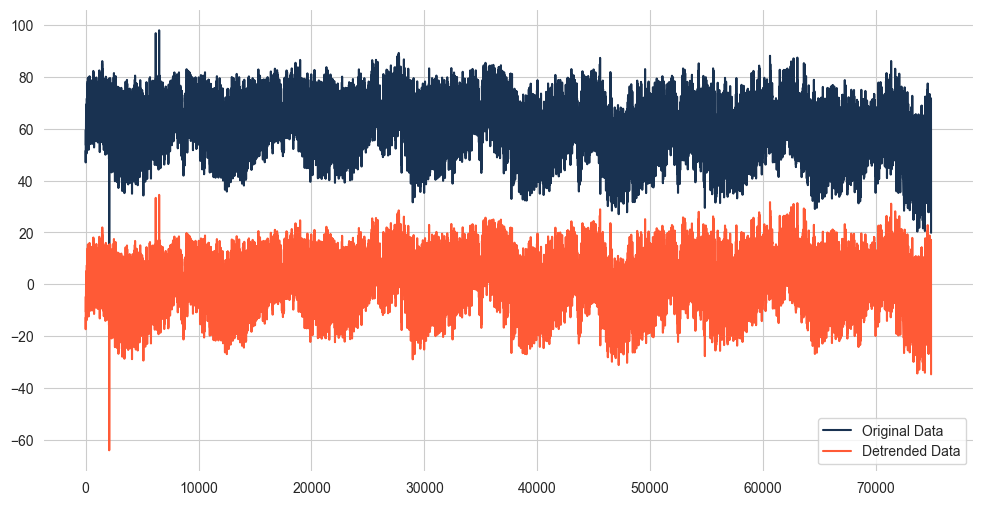

ADF Statistic: -18.269487
p-value: 0.000000


In [ ]:
#import the de-trending library
from scipy.signal import detrend
from statsmodels.tsa.stattools import adfuller
#from detrend import detrend

#apply the de-trending function to the target data
data_detrended = detrend(dfs[target])

#perform time series analysis on the de-trended data
from statsmodels.tsa.stattools import adfuller
result = adfuller(data_detrended)

plt.plot(dfs[target], label='Original Data')
plt.plot(data_detrended , label='Detrended Data')
plt.legend()
plt.show()

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

In [ ]:
#%pip install fbprophet
#%pip installProphet
#from fbprophet import Prophet

In [ ]:
#fitting the model on train data
#from fbprophet import Prophet

## Split the data into train and test sets
#dfarima = dfs[target]
#train_test_split_ratio = int(len(dfarima)*0.8)
#train, test = dfarima[:train_test_split_ratio], dfarima[train_test_split_ratio:]

#model = Prophet()
#model.fit(train)

#predicting on test data
#forecast = model.predict(test)

#plotting the results
#plt.figure(figsize=(20, 10))
#plt.plot(data['target'], label='Train')
#plt.plot(test['target'], label='Test')
#plt.plot(forecast['yhat'], label='Predicted')
#plt.legend(loc='best')
#plt.show()

In [ ]:
# Perform time series decomposition
#result = seasonal_decompose(dfs[target], model='additive', period=365)

# Split the data into train and test sets
dfarima = dfs[target]
train_test_split_ratio = int(len(dfarima)*0.8)
train, test = dfarima[:train_test_split_ratio], dfarima[train_test_split_ratio:]



# Fit an auto_arima model to the training set
#model = auto_arima(train, start_p=1, start_q=1, max_p=3, max_q=3, m=12, start_P=0, seasonal=True, d=1, D=1, trace=True, error_action='ignore', suppress_warnings=True)
#model = auto_arima(train, start_p=1, start_q=1, max_p=3, max_q=3, m=12, start_P=0, seasonal=True, d=1, D=1, trace=True, error_action='ignore', suppress_warnings=True)
model = auto_arima(train, seasonal= True,start_p=1,d=1, start_q=1,max_p=3,max_d=3,max_q=3,start_P=1, D=1,start_Q=1,max_P=3,max_D=3, stepwise= True)


model.fit(train)

# Make predictions on the test set
forecast = model.predict(n_periods=len(test))
forecast = pd.DataFrame(forecast,index = test.index,columns=['Prediction'])

# Plot the predictions against the actual values
plt.plot(train['target'], label='Train')
plt.plot(test['target'], label='Test')
plt.plot(forecast['Prediction'], label='Prediction')
plt.show()

KeyError: 'target'

In [ ]:
## Detrend the data using Scipy's signal package
from scipy.signal import detrend
detrended_data = detrend(dfs[target])

# Split the data into train and test sets
train_data = detrended_data[:int(len(detrended_data)*0.8)]
test_data = detrended_data[int(len(detrended_data)*0.8):]

# Perform time series analysis on the train and test sets
model = auto_arima(train_data, order=(1,1,1))
model_fit = model.fit(train_data)
predictions = model_fit.forecast(steps=len(test_data))[0]

# Plot the predicted and actual data
plt.plot(test_data, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.show()

AttributeError: 'ARIMA' object has no attribute 'forecast'

In [ ]:
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.adropna()

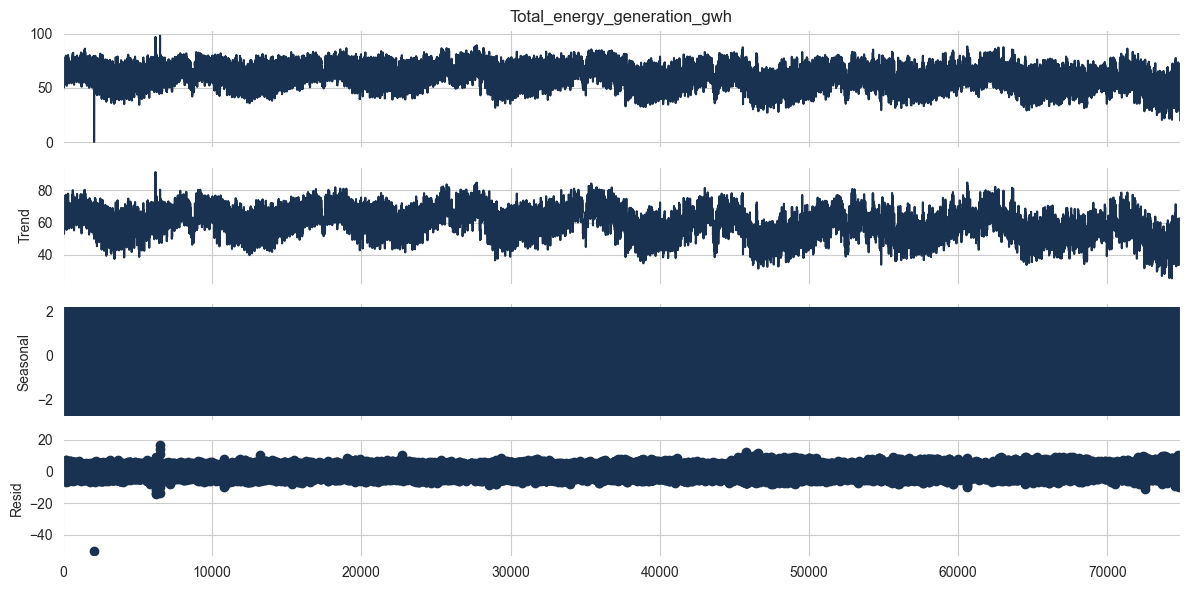

ADF Test Statistic : -16.636795
p-value : 0.000000


NotImplementedError: 
statsmodels.tsa.arima_model.ARMA and statsmodels.tsa.arima_model.ARIMA have
been removed in favor of statsmodels.tsa.arima.model.ARIMA (note the .
between arima and model) and statsmodels.tsa.SARIMAX.

statsmodels.tsa.arima.model.ARIMA makes use of the statespace framework and
is both well tested and maintained. It also offers alternative specialized
parameter estimators.


In [ ]:
#performing time series analysis
result = seasonal_decompose(dfs[target], model='additive', period=12)
result.plot()
plt.show()

#checking for stationarity
adf_test = adfuller(dfs[target])
print("ADF Test Statistic : %f"%adf_test[0])
print("p-value : %f"%adf_test[1])

#fitting the ARIMA model
model = auto_arima(train_data, order=(1,1,1))
model_fit = model.fit(train_data)
print(model_fit.summary())

#plotting the residuals
residuals = pd.DataFrame(model_fit.resid)
residuals.plot()
plt.title('Residuals Plot')
plt.show()

#plotting the predicted and actual values
predictions = model_fit.forecast(steps=len(data))[0]
plt.plot(dfs[target], label='Actual', c="green")
plt.plot(predictions, color='red', label='Predicted', c="red")
plt.title('Comparison of Actual and Predicted Values')
plt.legend()
plt.show()

#### Fit Auto_arima model

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        22:46:26   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

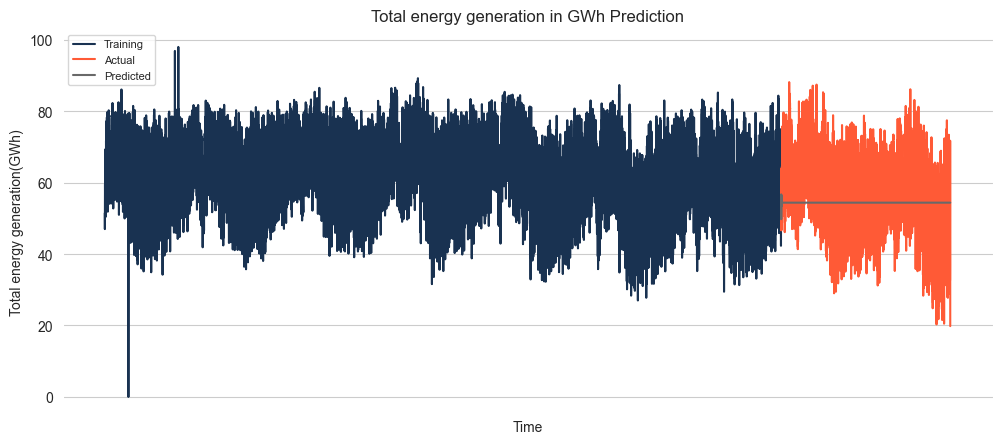

In [ ]:
# ARIMA Method
arima_model = auto_arima(train_data)

# Fit the final model with the order

#fitted_model = arima_model.fit(train_data)
#fitted_model = arima_model.fit(train_data, seasonal=False, stationary=False, test='kpss', stepwise=True, random_state=42) 
#fitted_model = arima_model.fit(train_data, seasonal=True, stationary=False, test='kpss', stepwise=True, random_state=42) 
fitted_model = arima_model.fit(train_data, seasonal=True, m=, start_p=, d=, start_q=, max_p=, max_d=   ) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Arima RMSE :- " + str(round(rms_auto_arima,3)))


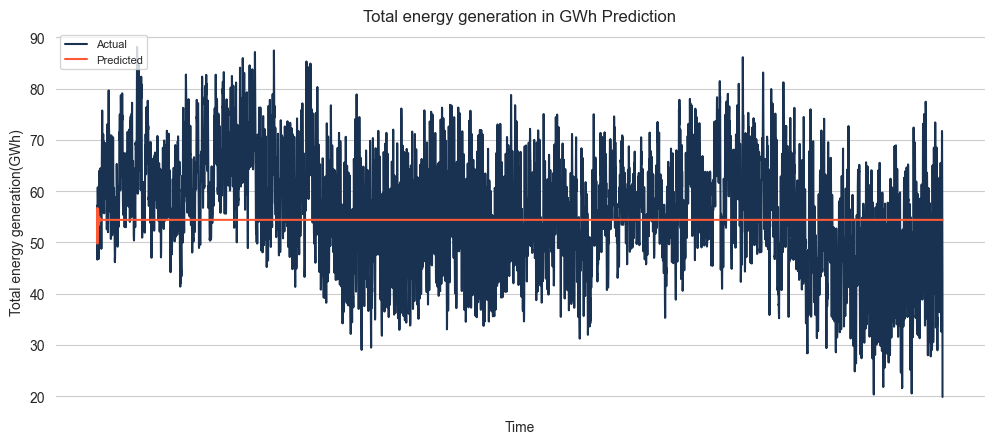

In [ ]:
# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
#plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

In [ ]:
df_arima = dfs[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]
##
##
# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

#### Fit Auto_arima model

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(5, 1, 1)   Log Likelihood             -106338.570
Date:                Tue, 25 Jul 2023   AIC                         212691.140
Time:                        23:55:07   BIC                         212754.144
Sample:                             0   HQIC                        212710.711
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6203      0.002    700.032      0.000       1.616       1.625
ar.L2         -0.6683      0.002   -390.986      0.000      -0.672      -0.665
ar.L3         -0.0455      0.004    -12.116      0.0

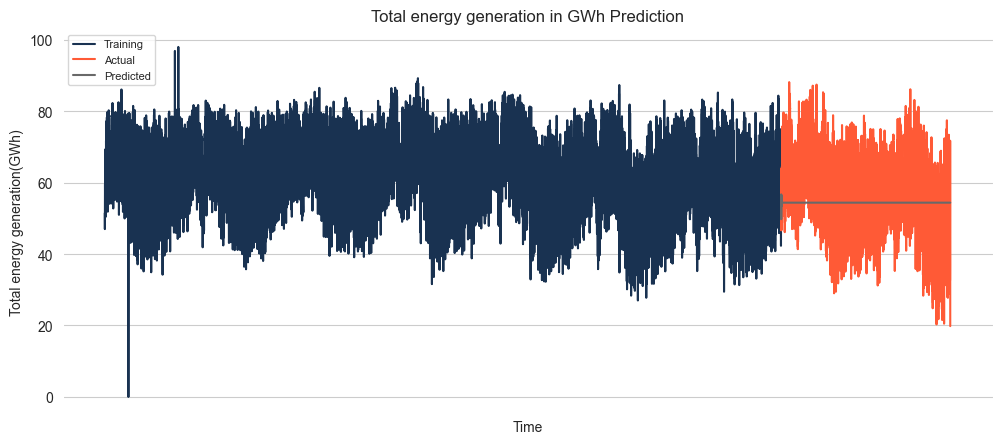

In [ ]:
# ARIMA Method
arima_model = auto_arima(train_data)

# Fit the final model with the order

#fitted_model = arima_model.fit(train_data)
fitted_model = arima_model.fit(train_data, seasonal=True, stationary=False, random_state=42) 
print(fitted_model.summary())

# Forecasting values
forecast_values = fitted_model.predict(len(test_data), alpha=0.01) 
# fcv_series = pd.Series(forecast_values[0], index=test_data.index)
fcv_series = forecast_values

# Plot the predicted stock price and original price
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train_data, label='Training')
plt.plot(test_data, label='Actual')
plt.plot(fcv_series,label='Predicted')
plt.title(title_main + ' ' + 'Prediction')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='upper left', fontsize=8)
#plt.show()

# Evaluate the model by calculating RMSE
rms_auto_arima = sqrt(mean_squared_error(test_data.values, fcv_series))
print("Arima RMSE :- " + str(round(rms_auto_arima,3)))


In [ ]:
## simple exponential method

In [ ]:
# Split data into train and test set
#window=365*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
df_arima = dfs[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]


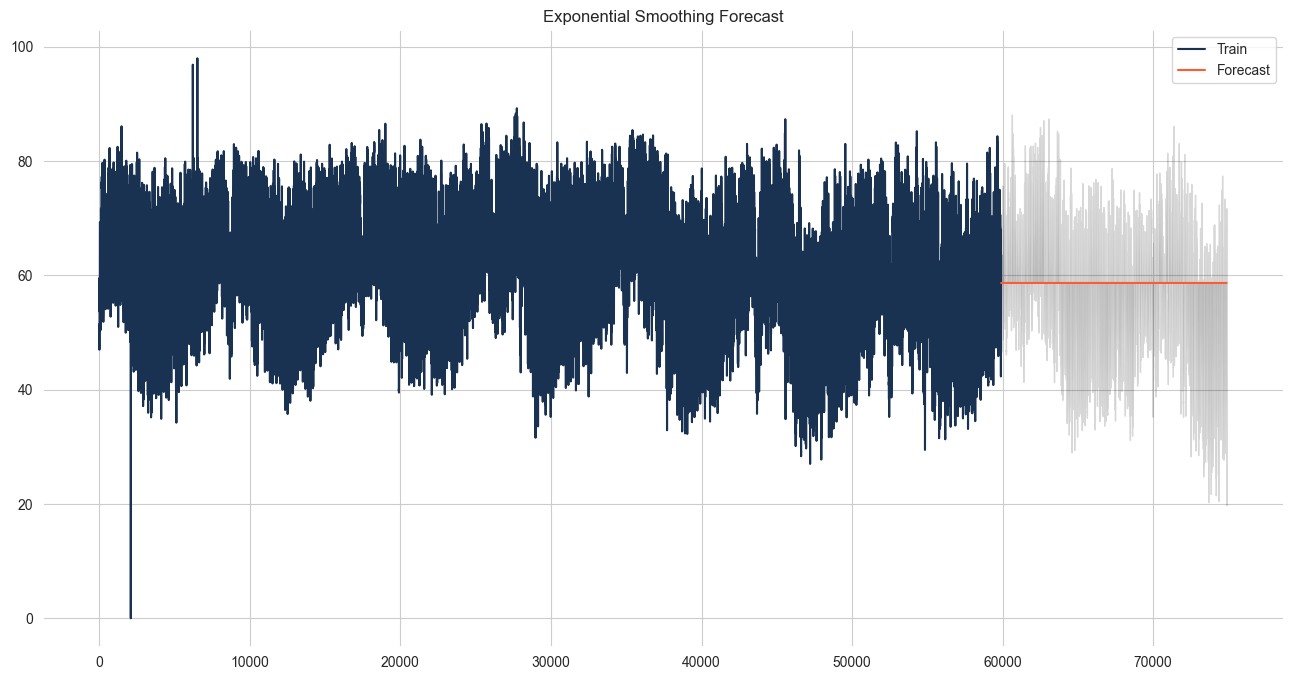

In [ ]:

#fitting the model
fit1 = ExponentialSmoothing(np.asarray(train_data)).fit()
#forecasting for test data
forecast_test = fit1.forecast(len(test_data))

#plotting the forecasted values
plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data.index, forecast_test, label='Forecast')
plt.fill_between(test_data.index, test_data, forecast_test, color='k', alpha=.15)
plt.title('Exponential Smoothing Forecast')
plt.legend(loc='best')
plt.show()

#### Simple exponential fitting

59903    56.531906
59904    56.531906
59905    56.531906
59906    56.531906
59907    56.531906
           ...    
74874    56.531906
74875    56.531906
74876    56.531906
74877    56.531906
74878    56.531906
Length: 14976, dtype: float64


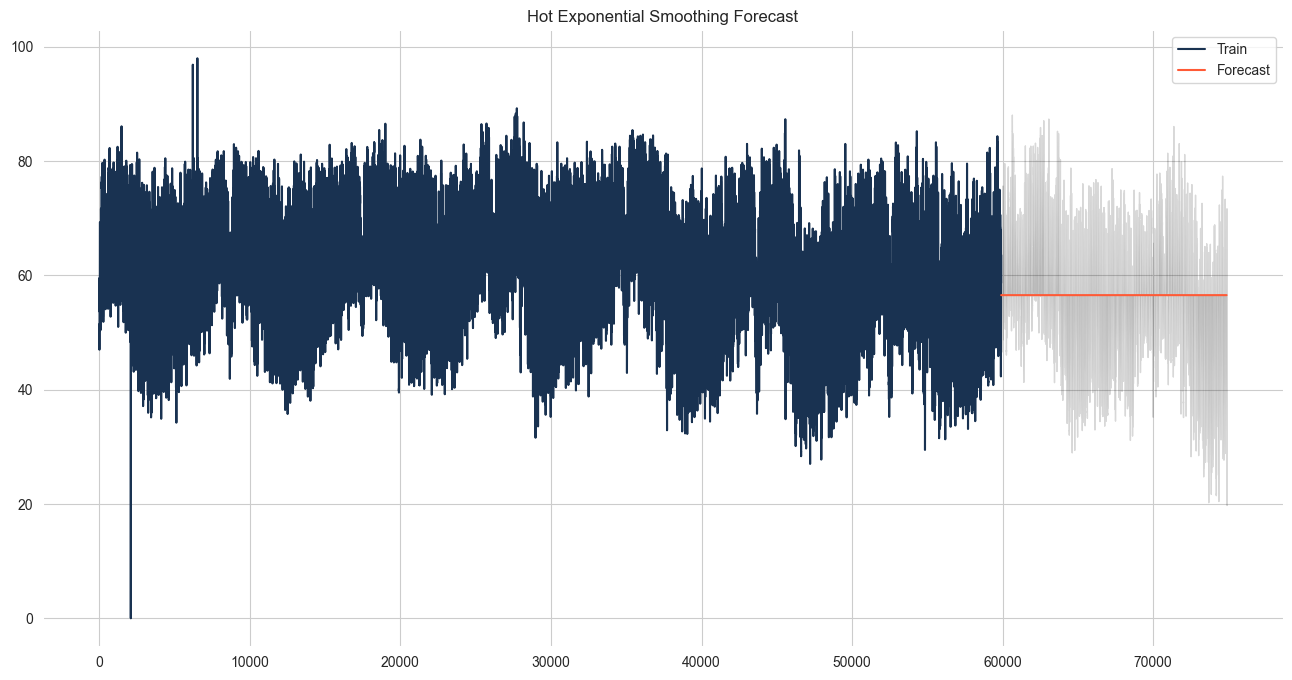

In [ ]:
#importing the necessary libraries
###import pandas as pd
###from statsmodels.tsa.holtwinters import ExponentialSmoothing

#reading the data

#fitting the model
model = SimpleExpSmoothing(train_data, initialization_method='estimated').fit(smoothing_level=0.1,optimized=True)

#making predictions
predictions = model.predict(start=test_data.index[0], end=test_data.index[-1])

#printing the predictions
print(predictions)


#plotting the forecasted values
plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data.index, predictions, label='Forecast')
plt.fill_between(test_data.index, test_data, predictions, color='k', alpha=.15)
plt.title('Hot Exponential Smoothing Forecast')
plt.legend(loc='best')
plt.show()

### Holt's Exponential Smoothing

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:83: RuntimeWarning: overflow encountered in matmul
  return err.T @ err


59903       56.671052
59904       54.930175
59905       53.349757
59906       51.524352
59907       49.441587
             ...     
74874   -28206.339375
74875   -28207.919793
74876   -28209.745198
74877   -28211.827963
74878   -28213.986501
Length: 14976, dtype: float64


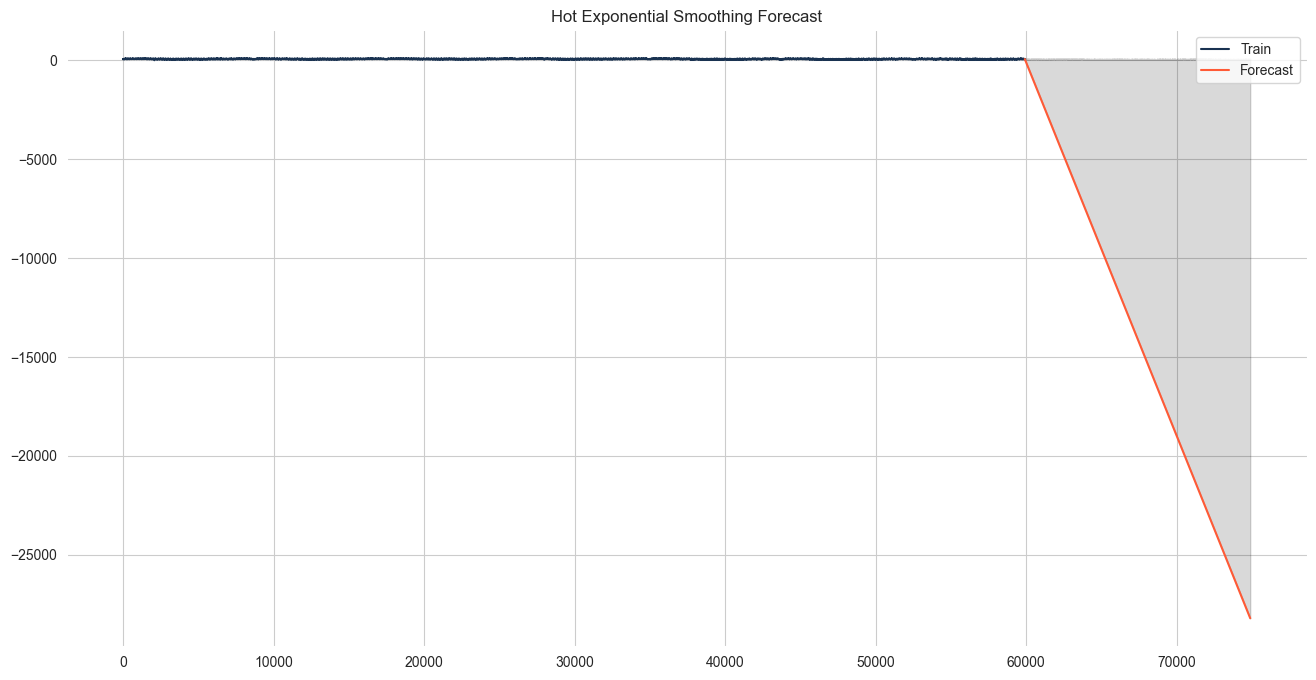

In [ ]:
#importing the necessary libraries
###import pandas as pd
###from statsmodels.tsa.holtwinters import ExponentialSmoothing

#reading the data

#fitting the model
#model = ExponentialSmoothing(train_data, seasonal_periods=365,seasonal='add', trend='add', initialization_method='estimated').fit()
model = ExponentialSmoothing(train_data, seasonal_periods=30,seasonal='add', trend='add', initialization_method='estimated').fit()

#making predictions
predictions = model.predict(start=test_data.index[0], end=test_data.index[-1])

#printing the predictions
print(predictions)


#plotting the forecasted values
plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data.index, predictions, label='Forecast')
plt.fill_between(test_data.index, test_data, predictions, color='k', alpha=.15)
plt.title('Hot Exponential Smoothing Forecast')
plt.legend(loc='best')
plt.show()

### Simple Exponential Smoothing

Simple Exponential Smoothing (SES) is used when the data doesn't contain any trend or seasonality. Smoothing Factor for level ($\alpha$) provides weightage to the influence of the observations. With larger values of $\alpha$ more attention is given to the most recent past observations whereas smaller values indicate that more past observations are being considered for forecasting. 

$$F_{t+1} = \alpha d_t + (1 - \alpha)F_t$$

In [ ]:
df_arima = dfs[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/

Simple Exponential Smoothing RMS :- 11.398 & Smoothing Level :- 0.12


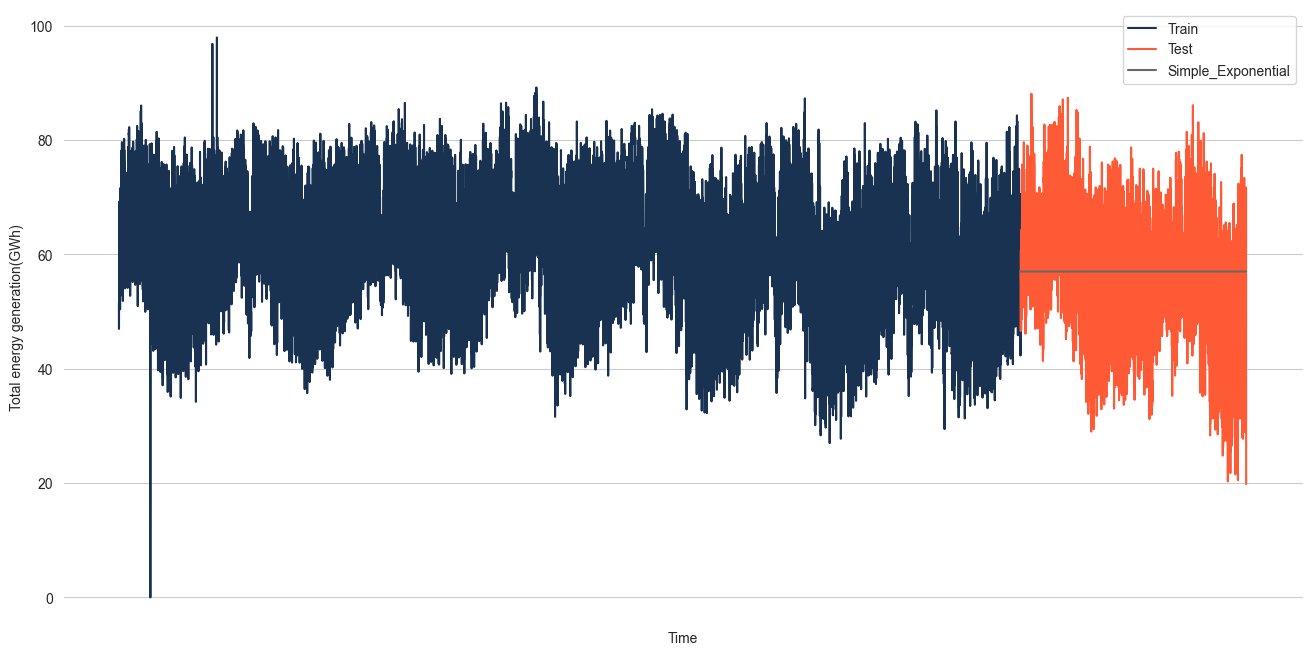

In [ ]:
# Simple Exponential Smoothing Method
pred_values = test_data.copy()
pred_values = pd.DataFrame(pred_values)

simple_exponential_df = pd.DataFrame(columns = ['RMS','Smoothing Level'])

from itertools import permutations
#perm = permutations(list(np.linspace(0.05,1,num=20)), 1)# origional
perm = permutations(list(np.linspace(0.01,1,num=10)), 2)
for i in list(perm):
    fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = i[0])
    pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential)),3)
    simple_exponential_df = pd.concat([simple_exponential_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]]})], ignore_index=True)

opt_values = simple_exponential_df.loc[simple_exponential_df['RMS'] == min(simple_exponential_df['RMS']),['Smoothing Level']].values


# Use optimised values from the lists
fit_sim_exp = SimpleExpSmoothing(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0])
pred_values['Simple_Exponential'] = fit_sim_exp.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')

rms_sim_exp = sqrt(mean_squared_error(test_data.values, pred_values.Simple_Exponential))
print("Simple Exponential Smoothing RMS :- " + str(round(rms_sim_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)))

#plt.savefig("visualisations/Energy_Simple_Exponential.png",dpi=300)

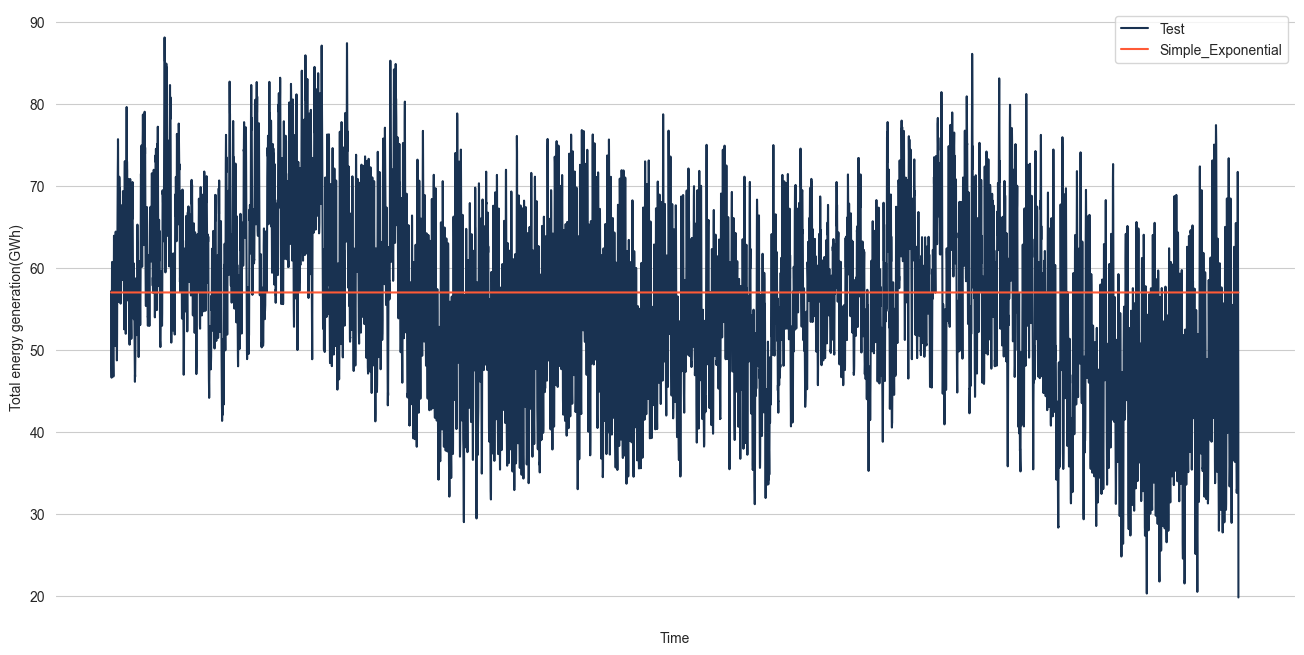

In [ ]:
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Simple_Exponential'], label='Simple_Exponential')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')

### Holt's Exponential Smoothing

Holt’s Exponential Smoothing takes the trend into account for forecasting the time series. We can use it when we have a trend but no seasonality in the data. It calculates the Smoothing value, which is the same used in SES for forecasting (first equation). Trend Coefficient (β) provides weightage to the difference in the consequent smoothing values and the previous trend estimate. The forecasting is a combination of the smoothing value and the trend estimate.

$$S_t = \alpha d_t + (1 - \alpha)F_t$$
$$b_t = \beta (S_t - S_{t-1}) + (1 - \beta) b_{t-1}$$
$$F_{t+1} = S_t + b_t$$

In [ ]:
# Split data into train and test set
#window=365*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
df_arima = data_df[target]#dfs[target]
train_test_split_ratio = int(len(df_arima)*0.8)
train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_61528/3579756626.py:7: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_61528/3579756626.py:7: FutureWarning: the 'smoothing_slope' keyword is deprecated, use 'smoothing_trend' instead.
  fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/pandas/util/_decorators.py:210: Estimat

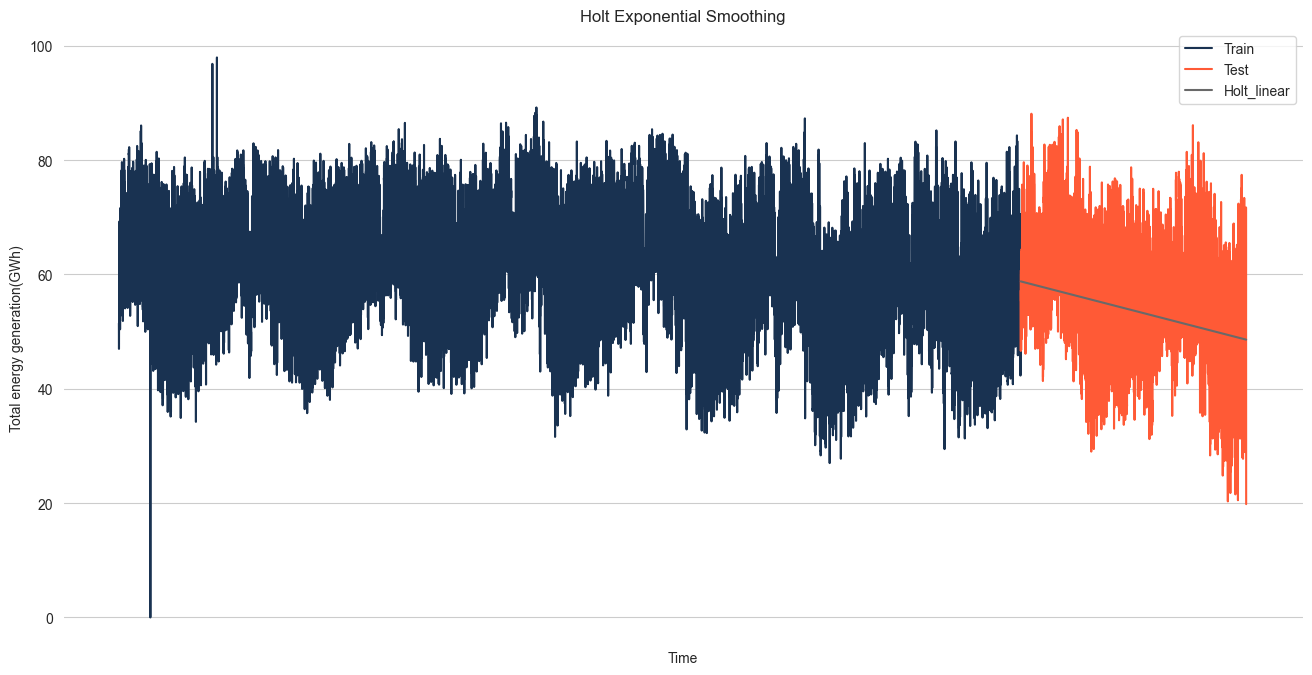

In [ ]:
# Holt's Exponential Smoothing Method
holt_linear_df = pd.DataFrame(columns = ['RMS','Smoothing Level','Smoothing Slope'])

perm = permutations(list(np.linspace(0.05,1,num=20)), 2)
#perm = permutations(list(np.linspace(0.01,1,num=10)), 2)
for i in list(perm):
    fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = i[0],smoothing_slope=i[1])
    pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

    rms = round(sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear)),3)
    #holt_linear_df = holt_linear_df.append(other = {'RMS' : rms , 'Smoothing Level' : i[0], 'Smoothing Slope':i[1]} , ignore_index=True)
    holt_linear_df = pd.concat([holt_linear_df, pd.DataFrame({'RMS' : [rms] , 'Smoothing Level' : [i[0]], 'Smoothing Slope':[i[1]]})], ignore_index=True)

opt_values = holt_linear_df.loc[holt_linear_df['RMS'] == min(holt_linear_df['RMS']),['Smoothing Level','Smoothing Slope']].values


# Using optimised values from the lists.
fit_holt = Holt(np.asarray(train_data)).fit(smoothing_level = opt_values[0][0],smoothing_slope=opt_values[0][1])
pred_values['Holt_linear'] = fit_holt.forecast(len(test_data))

plt.figure(figsize=(16,8))
plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')
#plt.savefig("visualisations/Stock_Holt_winters.png",dpi=300)
rms_holt_exp = sqrt(mean_squared_error(test_data.values, pred_values.Holt_linear))
#print("Holt’s Exponential Smoothing RMS :- " + str(round(rms_holt_exp,3)) + " & Smoothing Level :- "+str(round(opt_values[0][0],3)) + " & Smoothing Slope :- "+str(round(opt_values[0][1],3)))


In [ ]:
plt.figure(figsize=(16,8))
#plt.plot(train_data, label='Train')
plt.plot(test_data, label='Test')
plt.plot(pred_values['Holt_linear'], label='Holt_linear')
plt.xlabel('Time')
plt.ylabel(ylable_target)
plt.xticks([])
plt.legend(loc='best')
plt.title('Holt Exponential Smoothing')

#### New approach 

##### split the data into train and test set using .....

In [ ]:
df_arima_tstn = data_df[target]
#test_percent = 0.3#0.15
test_percent = 0.15
test_number = int(df_arima_tstn.shape[0]*test_percent)
train_s = df_arima_tstn[:-test_number]
test_s = df_arima_tstn[-test_number:]

train_s.shape, test_s.shape


((63648,), (11231,))

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_s = SARIMAX(train_s, order=(6,1,6), 
                enforce_stationarity=False, 
                enforce_invertibility=False,
                trend="t") # order of _ for AR, 1 differentiation, and _ for MA
model_fit_s = model_s.fit(maxiter=2000)

print('Coefficients: %s' % model_fit_s.params)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           14     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.85109D+00    |proj g|=  7.12576D+03


 This problem is unconstrained.

   evaluations in the last line search.  Termination
   may possibly be caused by a bad search direction.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   14      1     18      1     0     0   7.126D+03   1.851D+00
  F =   1.8510870127493348     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
Coefficients: drift     4.563747e-09
ar.L1     3.433134e-01
ar.L2     4.567965e-01
ar.L3     7.931571e-02
ar.L4     1.611438e-01
ar.L5     4.603376e-01
ar.L6    -6.792296e-01
ma.L1     2.790829e-01
ma.L2    -2.980007e-01
ma.L3    -3.810818e-01
ma.L4    -4.749213e-01
ma.L5    -8.317725e-01
ma.L6    -3.024901e-03
sigma2    1.882430e+00
dtype: float64


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


RMSE:  20.716424507681804


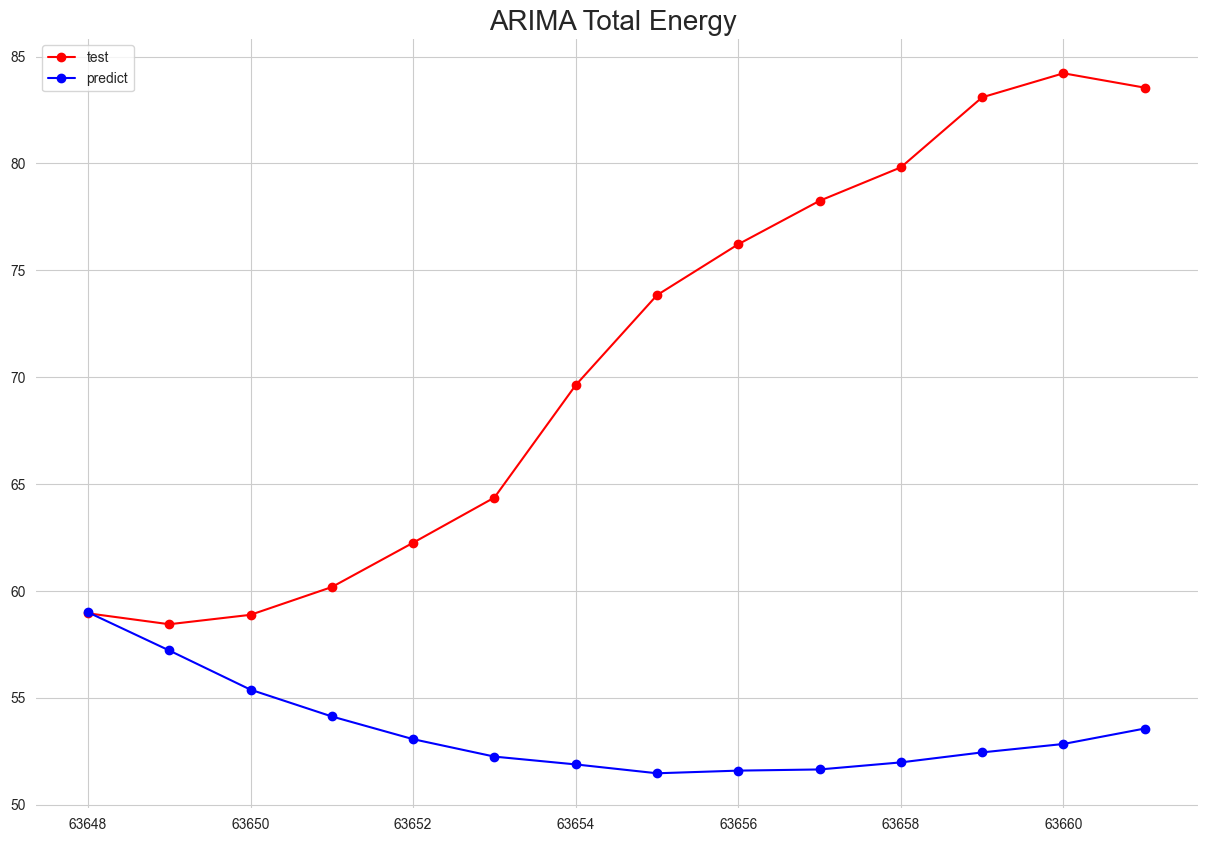

In [ ]:
#from sklearn.metrics import mean_squared_error
#from math import sqrt

predictions = model_fit_s.predict(start=len(train_s), end=len(train_s)+len(test_s)-1, typ="levels", index= test_s.index)

print("RMSE: ", sqrt(mean_squared_error(test_s[:14], predictions[:14])))
plt.figure(figsize=(15,10))
plt.plot(test_s[:14], c="red", label="test", marker='o')
plt.plot(predictions[:14], c="blue", label="predict", marker='o')
plt.legend()
plt.title('ARIMA Total Energy ', fontsize=(20))
plt.show();

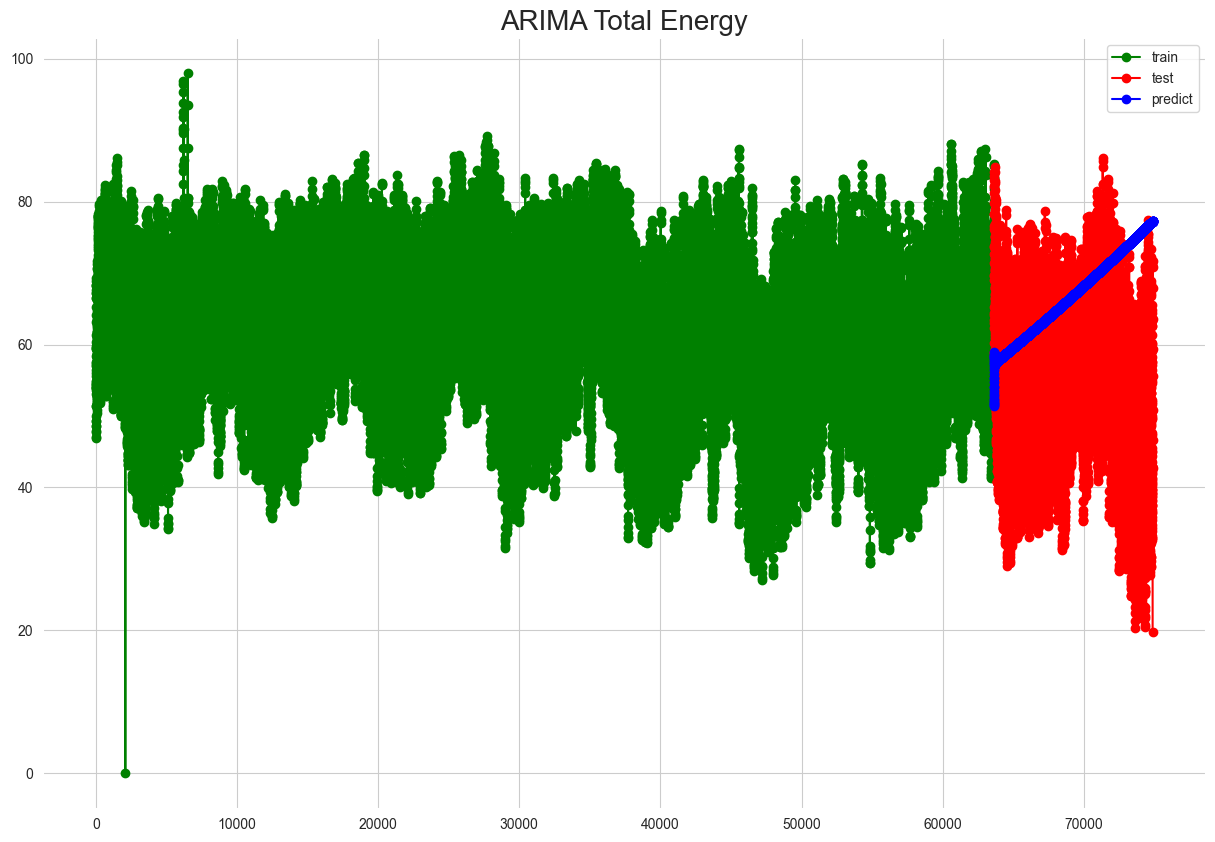

In [ ]:
plt.figure(figsize=(15,10))
plt.plot(train_s, c="green", label="train", marker='o')
plt.plot(test_s, c="red", label="test", marker='o')
plt.plot(predictions, c="blue", label="predict", marker='o')
plt.legend()
plt.title('ARIMA Total Energy', fontsize=(20))
plt.show();

#### This is check the mean absolute error

In [ ]:
from sklearn.metrics import mean_absolute_error
print("MAE: ", mean_absolute_error(test_s[:14], predictions[:14]))

MAE:  6.962666671769306


/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


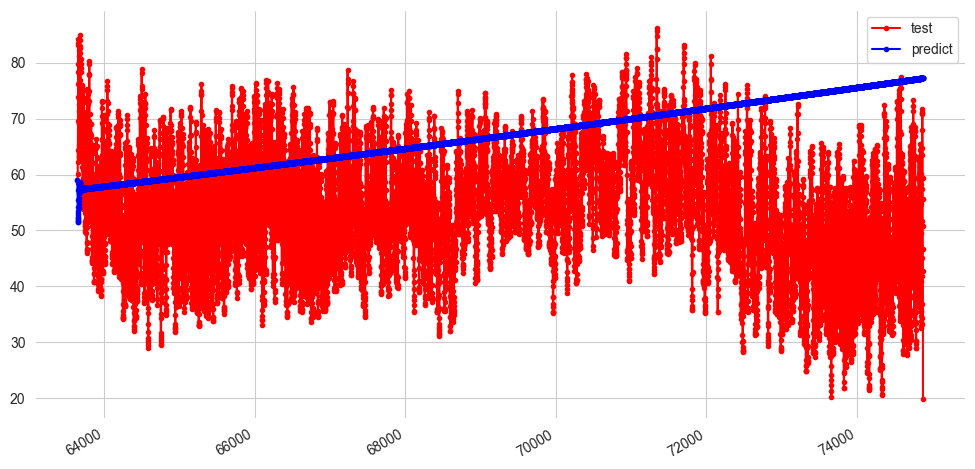

In [ ]:
# make prediction
predictions = model_fit_s.predict(start=len(train_s), end=len(train_s)+len(test_s)-1, typ="levels", index=test_s.index)

fig = plt.figure()
plt.plot(test_s, c="red", label="test", marker='.')
plt.plot(predictions, c="blue", label="predict", marker='.')
plt.legend()
fig.autofmt_xdate()
plt.show();

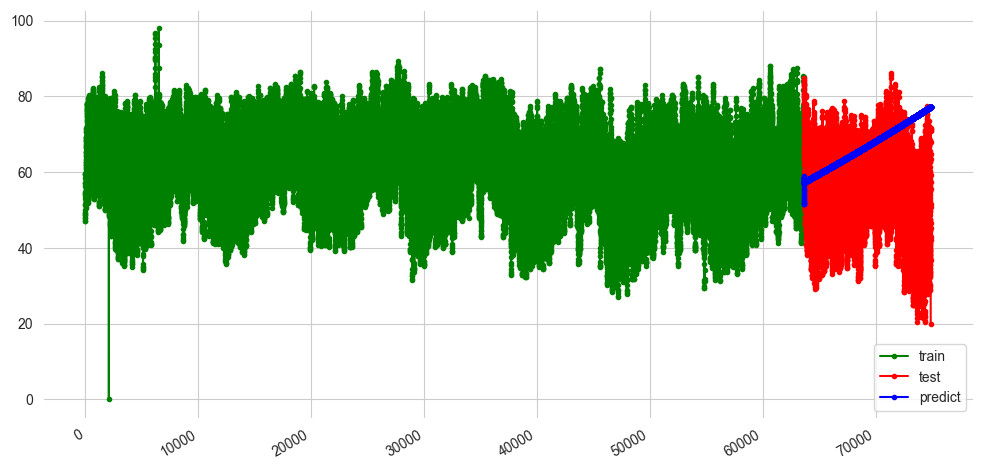

In [ ]:

fig = plt.figure()
plt.plot(train_s, c="green", label="train", marker='.')
plt.plot(test_s, c="red", label="test", marker='.')
plt.plot(predictions, c="blue", label="predict", marker='.')
plt.legend()
fig.autofmt_xdate()
plt.show();

## F-prohpet

In [ ]:
#%pip install fbprophet
#%pip installProphet
#from fbprophet import Prophet

In [ ]:
# what prophet does
# y(t) = T(t) + S(t) + H(t)

In [ ]:
# set up data for prohpet 
dfs = data_df[['Date',  target]]
dfs_d = data_df[target]
x = 'Date'
y = target
dfs

In [ ]:
print(dfs.shape)
plt.figure()
plt.plot(dfs['Date'], dfs[target])
plt.autoscale(enable=True, axis='x', tight=True)
plt.show();

In [ ]:
# Split the data up
#train = dfs.loc[dfs[x].dt.year < 2022,:]
#test = dfs.loc[dfs[x].dt.year >= 2022, :]
#test_number = 274
#print(train.shape, test.shape)

#plt.figure(figsize=(15,5))
#plt.plot(train[x],train[y].values, c="blue", label="train")
#plt.plot(test[x], test[y].values, c="red", label="test")
#plt.autoscale(enable=True, axis=x, tight=True)
#plt.legend()
#plt.show();